# ATOM Sumo: Detailed Test Results Analysis

This notebook collects and visualizes the main measured test evidence for the `ATOM Sumo` prototype.

Covered datasets:

- HTTP control latency
- straight-line speed
- straightness / drift
- turn-in-place timing
- automatic ToF stop-distance behavior
- static ToF accuracy
- power brownout / reset behavior

The notebook is intended as the main Jupyter evidence file for Verstapost review.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [
    cwd / "tests" / "results",   # repository root
    cwd / "results",             # tests folder
    cwd.parent / "results",      # tests/notebooks folder
    cwd / "analysis" / "results",# legacy repository root
]
for candidate in candidates:
    if candidate.exists():
        RESULTS = candidate
        ROOT = candidate.parent.parent if candidate.parent.name == "tests" else candidate.parent
        break
else:
    raise FileNotFoundError(
        "Could not find test results. Run this notebook from the repository root, tests folder, or tests/notebooks folder."
    )

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

def read_csv(name):
    path = RESULTS / name
    df = pd.read_csv(path)
    return df

csv_files = sorted(RESULTS.glob("*.csv"))
inventory = pd.DataFrame(
    {
        "file": [p.name for p in csv_files],
        "rows": [len(pd.read_csv(p)) for p in csv_files],
        "bytes": [p.stat().st_size for p in csv_files],
    }
)
inventory


,file,rows,bytes
0,auto_behavior_operator_observation.csv,1,255
1,camera_homography_points.csv,6,173
2,camera_homography_points_template.csv,6,101
3,camera_homography_residuals.csv,6,322
4,color_repeatability_test.csv,9,918
5,http_latency_2026-04-11_18-28-33.csv,120,3889
6,http_latency_2026-04-11_19-34-31.csv,120,3827
7,http_latency_2026-04-11_19-38-18_medium_speed.csv,120,3887
8,http_latency_2026-05-30_15-40-08_speed0.csv,120,3813
9,http_latency_2026-05-30_15-41-58_speed0.csv,120,3816


## 1. HTTP Control Latency

The latency tests measure request-response time for `/move?dir=forward` and `/move?dir=stop`.
They are control-path measurements, not physical wheel-start measurements.


In [2]:
latency_runs = {
    "2026-04-11 pre-fix speed0": "http_latency_2026-04-11_18-28-33.csv",
    "2026-04-11 fixed speed0": "http_latency_2026-04-11_19-34-31.csv",
    "2026-04-11 fixed speed180": "http_latency_2026-04-11_19-38-18_medium_speed.csv",
    "2026-05-30 speed0 run1": "http_latency_2026-05-30_15-40-08_speed0.csv",
    "2026-05-30 speed0 run2": "http_latency_2026-05-30_15-41-58_speed0.csv",
    "2026-05-30 speed180": "http_latency_2026-05-30_15-42-18_speed180.csv",
}

latency_frames = []
summary_rows = []
endpoint_rows = []

for label, filename in latency_runs.items():
    df = read_csv(filename)
    df["run"] = label
    latency_frames.append(df)
    summary_rows.append(
        {
            "run": label,
            "count": len(df),
            "median_ms": df["latency_ms"].median(),
            "p95_ms": df["latency_ms"].quantile(0.95),
            "max_ms": df["latency_ms"].max(),
        }
    )
    for endpoint, group in df.groupby("endpoint"):
        endpoint_rows.append(
            {
                "run": label,
                "endpoint": endpoint,
                "count": len(group),
                "median_ms": group["latency_ms"].median(),
                "p95_ms": group["latency_ms"].quantile(0.95),
                "max_ms": group["latency_ms"].max(),
            }
        )

latency_all = pd.concat(latency_frames, ignore_index=True)
latency_summary = pd.DataFrame(summary_rows)
endpoint_summary = pd.DataFrame(endpoint_rows)
latency_summary.round(3)


,run,count,median_ms,p95_ms,max_ms
0,2026-04-11 pre-fix speed0,120,127.809,162.072,274.227
1,2026-04-11 fixed speed0,120,31.538,53.178,68.883
2,2026-04-11 fixed speed180,120,87.372,158.048,186.038
3,2026-05-30 speed0 run1,120,18.565,42.344,73.677
4,2026-05-30 speed0 run2,120,17.319,54.800,71.143
5,2026-05-30 speed180,120,65.684,82.119,101.888


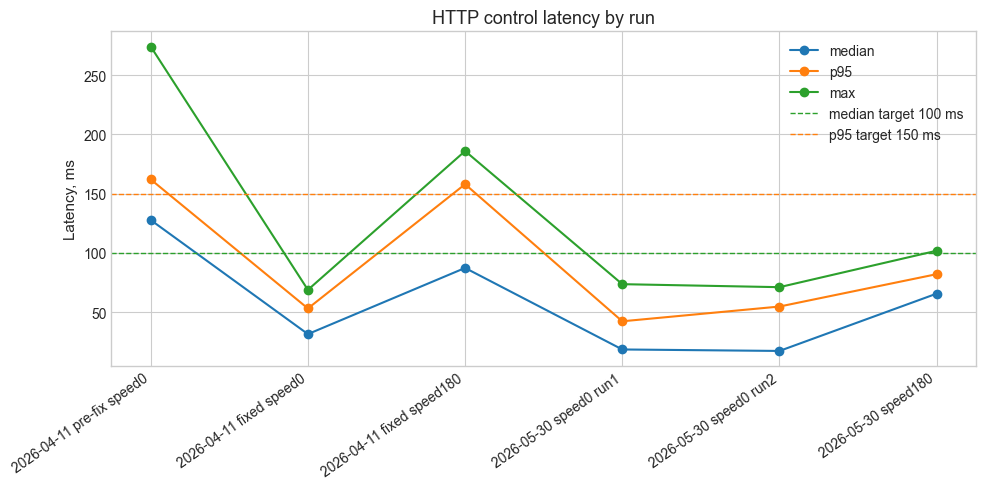

In [3]:
fig, ax = plt.subplots()
x = range(len(latency_summary))
ax.plot(x, latency_summary["median_ms"], marker="o", label="median")
ax.plot(x, latency_summary["p95_ms"], marker="o", label="p95")
ax.plot(x, latency_summary["max_ms"], marker="o", label="max")
ax.axhline(100, color="tab:green", linestyle="--", linewidth=1, label="median target 100 ms")
ax.axhline(150, color="tab:orange", linestyle="--", linewidth=1, label="p95 target 150 ms")
ax.set_xticks(list(x))
ax.set_xticklabels(latency_summary["run"], rotation=35, ha="right")
ax.set_ylabel("Latency, ms")
ax.set_title("HTTP control latency by run")
ax.legend()
plt.tight_layout()
plt.show()


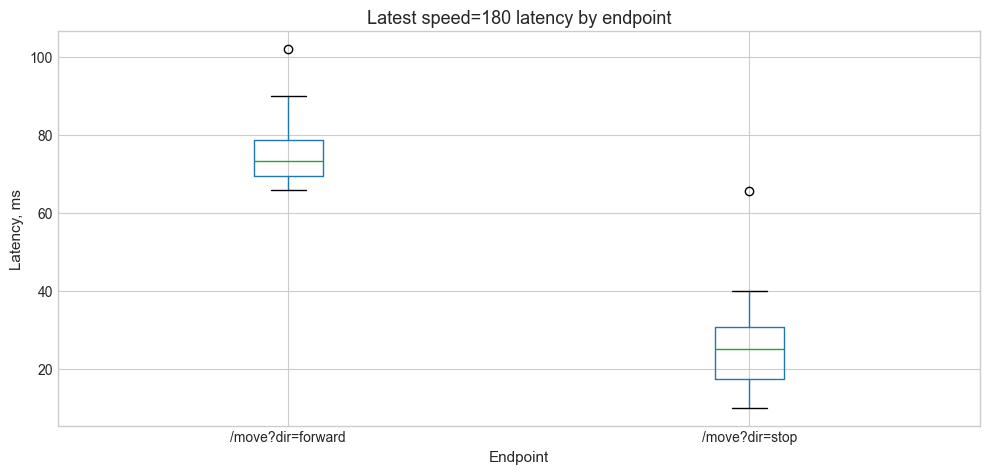

,run,endpoint,count,median_ms,p95_ms,max_ms
0,2026-04-11 pre-fix speed0,/move?dir=forward,60,138.029,167.943,274.227
1,2026-04-11 pre-fix speed0,/move?dir=stop,60,18.833,78.363,125.706
2,2026-04-11 fixed speed0,/move?dir=forward,60,30.623,53.178,68.883
3,2026-04-11 fixed speed0,/move?dir=stop,60,32.673,51.061,67.651
4,2026-04-11 fixed speed180,/move?dir=forward,60,147.644,167.672,186.038
5,2026-04-11 fixed speed180,/move?dir=stop,60,32.405,39.333,44.610
6,2026-05-30 speed0 run1,/move?dir=forward,60,15.614,38.092,67.271
7,2026-05-30 speed0 run1,/move?dir=stop,60,21.866,43.140,73.677
8,2026-05-30 speed0 run2,/move?dir=forward,60,16.644,31.771,62.663
9,2026-05-30 speed0 run2,/move?dir=stop,60,18.345,58.765,71.143


In [4]:
latest = latency_all[latency_all["run"] == "2026-05-30 speed180"]
fig, ax = plt.subplots()
latest.boxplot(column="latency_ms", by="endpoint", ax=ax)
ax.set_title("Latest speed=180 latency by endpoint")
ax.set_xlabel("Endpoint")
ax.set_ylabel("Latency, ms")
plt.suptitle("")
plt.tight_layout()
plt.show()

endpoint_summary.round(3)


## 2. Movement Speed

The speed test measures time over a straight `1.0 m` path at several PWM values.


In [5]:
speed = read_csv("movement_speed_test.csv")
speed_summary = (
    speed.groupby("pwm")
    .agg(
        trials=("speed_m_s", "count"),
        mean_speed_m_s=("speed_m_s", "mean"),
        std_speed_m_s=("speed_m_s", "std"),
        min_speed_m_s=("speed_m_s", "min"),
        max_speed_m_s=("speed_m_s", "max"),
    )
    .reset_index()
)
speed_summary.round(3)


,pwm,trials,mean_speed_m_s,std_speed_m_s,min_speed_m_s,max_speed_m_s
0,80,3,0.205,0.004,0.201,0.208
1,150,3,0.385,0.003,0.382,0.388
2,180,3,0.465,0.010,0.455,0.474
3,255,3,0.610,0.034,0.578,0.645


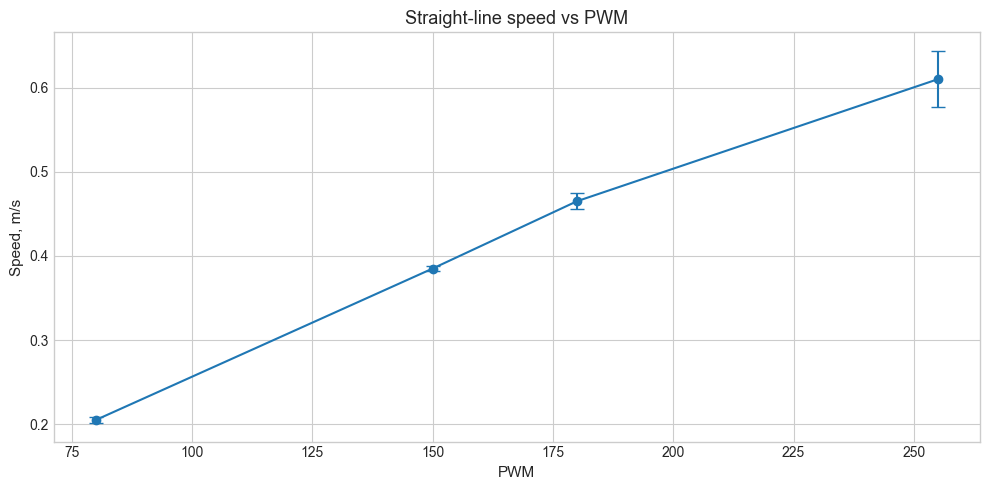

In [6]:
fig, ax = plt.subplots()
ax.errorbar(
    speed_summary["pwm"],
    speed_summary["mean_speed_m_s"],
    yerr=speed_summary["std_speed_m_s"].fillna(0),
    fmt="o-",
    capsize=5,
)
ax.set_title("Straight-line speed vs PWM")
ax.set_xlabel("PWM")
ax.set_ylabel("Speed, m/s")
plt.tight_layout()
plt.show()


## 3. Straightness / Drift

Drift is measured after a `1.0 m` forward run. Positive values below are shown as left/right categories.


In [7]:
drift = read_csv("movement_drift_test.csv")
drift_summary = (
    drift.groupby(["pwm", "direction"])
    .agg(trials=("drift_cm", "count"), mean_drift_cm=("drift_cm", "mean"), max_drift_cm=("drift_cm", "max"))
    .reset_index()
)
drift_summary.round(2)


,pwm,direction,trials,mean_drift_cm,max_drift_cm
0,80,left,3,8.03,8.4
1,150,left,3,11.17,14.3
2,180,left,4,7.70,9.8
3,255,left,3,5.63,6.8
4,255,right,1,1.60,1.6


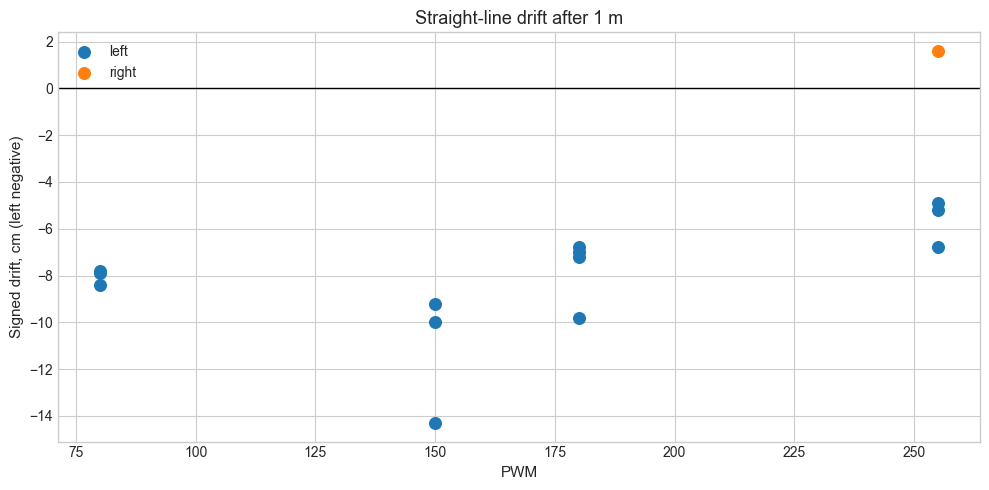

In [8]:
fig, ax = plt.subplots()
for direction, group in drift.groupby("direction"):
    signed = group["drift_cm"] * (-1 if direction == "left" else 1)
    ax.scatter(group["pwm"], signed, label=direction, s=70)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Straight-line drift after 1 m")
ax.set_xlabel("PWM")
ax.set_ylabel("Signed drift, cm (left negative)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Turn-In-Place Timing

Turn tests record time for approximate `180 deg` turns in both directions.


In [9]:
turn = read_csv("movement_turn_test.csv")
turn_summary = (
    turn.groupby(["pwm", "direction"])
    .agg(trials=("time_s", "count"), mean_time_s=("time_s", "mean"), std_time_s=("time_s", "std"))
    .reset_index()
)
turn_summary.round(3)


,pwm,direction,trials,mean_time_s,std_time_s
0,150,left,3,0.867,0.091
1,150,right,3,0.997,0.035
2,180,left,3,0.733,0.035
3,180,right,3,0.740,0.085
4,255,left,3,0.597,0.121
5,255,right,3,0.647,0.050


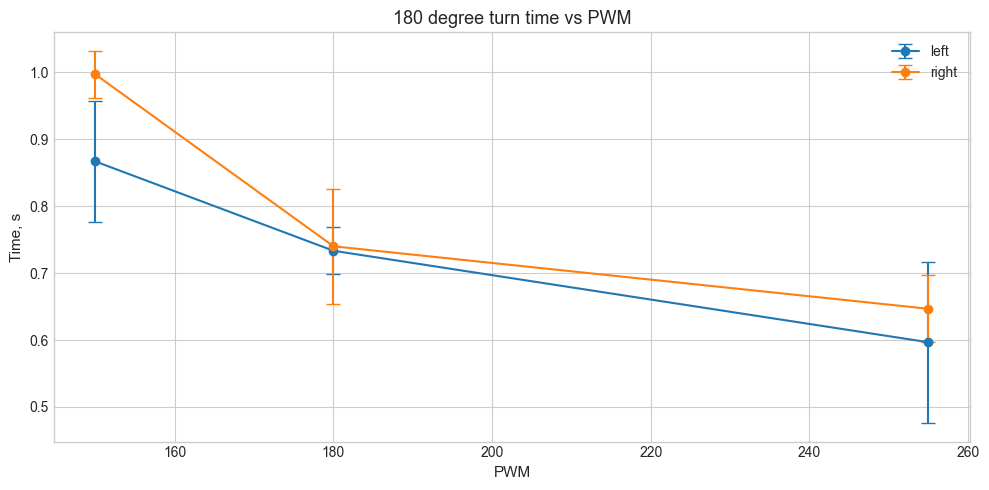

In [10]:
fig, ax = plt.subplots()
for direction, group in turn_summary.groupby("direction"):
    ax.errorbar(group["pwm"], group["mean_time_s"], yerr=group["std_time_s"].fillna(0), marker="o", capsize=5, label=direction)
ax.set_title("180 degree turn time vs PWM")
ax.set_xlabel("PWM")
ax.set_ylabel("Time, s")
ax.legend()
plt.tight_layout()
plt.show()


## 5. ToF Automatic Stop-Distance Test

This is the main stop-distance evidence. The robot drives toward an obstacle with ToF stop enabled and the final distance is recorded.


In [11]:
tof_stop = read_csv("tof_stop_test.csv")
tof_stop_summary = (
    tof_stop.groupby(["pwm", "threshold_mm", "result"])
    .agg(trials=("actual_stop_distance_cm", "count"), mean_stop_cm=("actual_stop_distance_cm", "mean"), min_stop_cm=("actual_stop_distance_cm", "min"))
    .reset_index()
)
tof_stop_summary.round(2)


,pwm,threshold_mm,result,trials,mean_stop_cm,min_stop_cm
0,80,250,stopped,3,10.57,10.2
1,80,300,stopped,3,17.53,16.0
2,80,400,stopped,3,27.23,26.5
3,150,400,stopped,3,12.90,11.6
4,255,400,collision,1,7.20,7.2


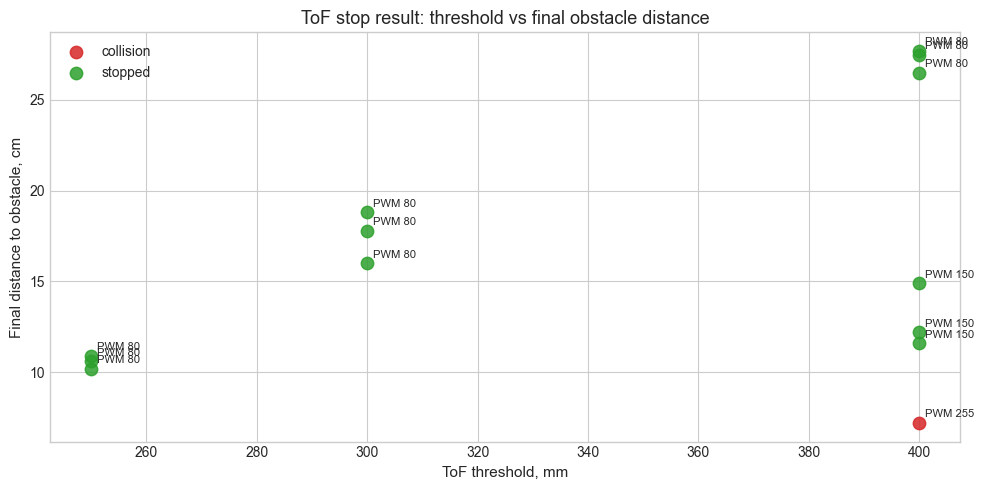

In [12]:
fig, ax = plt.subplots()
colors = {"stopped": "tab:green", "collision": "tab:red"}
for result, group in tof_stop.groupby("result"):
    ax.scatter(
        group["threshold_mm"],
        group["actual_stop_distance_cm"],
        s=80,
        c=colors.get(result, "tab:gray"),
        label=result,
        alpha=0.85,
    )
    for _, row in group.iterrows():
        ax.annotate(f"PWM {row['pwm']}", (row["threshold_mm"], row["actual_stop_distance_cm"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("ToF stop result: threshold vs final obstacle distance")
ax.set_xlabel("ToF threshold, mm")
ax.set_ylabel("Final distance to obstacle, cm")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Static ToF Accuracy

Static ToF readings are compared against known distances. The current dataset shows that the sensor responds, but has a large mounting/calibration offset.


In [13]:
tof_acc = read_csv("tof_accuracy_test.csv")
tof_acc_summary = (
    tof_acc.groupby("actual_mm")
    .agg(
        trials=("measured_mm", "count"),
        mean_measured_mm=("measured_mm", "mean"),
        mean_error_mm=("error_mm", "mean"),
        min_error_mm=("error_mm", "min"),
        max_error_mm=("error_mm", "max"),
    )
    .reset_index()
)
tof_acc_summary.round(1)


,actual_mm,trials,mean_measured_mm,mean_error_mm,min_error_mm,max_error_mm
0,50,3,113.7,63.7,62,65
1,100,3,170.3,70.3,66,77
2,200,3,271.3,71.3,63,76
3,300,3,331.0,31.0,26,35
4,500,3,362.3,-137.7,-210,-45


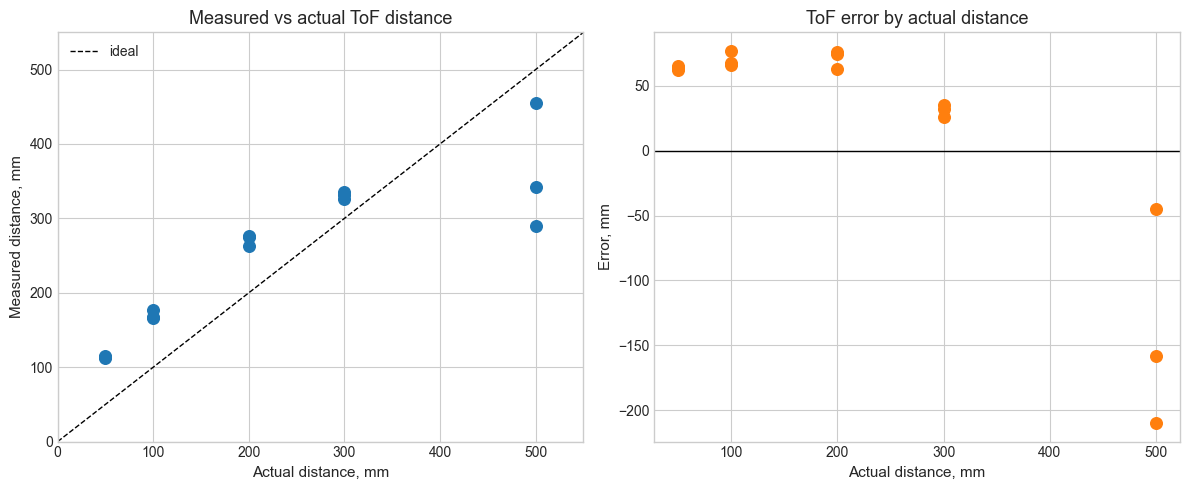

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(tof_acc["actual_mm"], tof_acc["measured_mm"], s=70)
lim = [0, max(tof_acc["actual_mm"].max(), tof_acc["measured_mm"].max()) + 50]
ax1.plot(lim, lim, "k--", linewidth=1, label="ideal")
ax1.set_xlim(lim)
ax1.set_ylim(lim)
ax1.set_title("Measured vs actual ToF distance")
ax1.set_xlabel("Actual distance, mm")
ax1.set_ylabel("Measured distance, mm")
ax1.legend()

ax2.axhline(0, color="black", linewidth=1)
ax2.scatter(tof_acc["actual_mm"], tof_acc["error_mm"], s=70, color="tab:orange")
ax2.set_title("ToF error by actual distance")
ax2.set_xlabel("Actual distance, mm")
ax2.set_ylabel("Error, mm")
plt.tight_layout()
plt.show()


## 7. Power Brownout / Reset Test

The power test sends movement commands at several PWM settings and checks whether the main controller, Wi-Fi, cameras, or color endpoint fail during the run.

Important interpretation:

- `reset_observed = no` and `wifi_disconnect = no` are good for the main controller.
- `camera_loss = yes` means camera endpoints were not reachable during this test and should be re-tested with cameras confirmed online.


In [15]:
brownout = read_csv("power_brownout_test.csv")
brownout_summary = (
    brownout.groupby(["pwm", "command"])
    .agg(
        trials=("trial", "count"),
        resets=("reset_observed", lambda s: (s != "no").sum()),
        wifi_disconnects=("wifi_disconnect", lambda s: (s == "yes").sum()),
        camera_losses=("camera_loss", lambda s: (s == "yes").sum()),
    )
    .reset_index()
)
brownout_summary


,pwm,command,trials,resets,wifi_disconnects,camera_losses
0,80,backward,10,0,0,8
1,80,forward,10,0,0,8
2,80,left,10,1,1,8
3,80,right,10,2,2,9
4,80,stop,10,2,2,9
5,150,backward,10,2,2,8
6,150,forward,10,2,2,8
7,150,left,10,1,1,6
8,150,right,10,1,1,8
9,150,stop,10,1,1,6


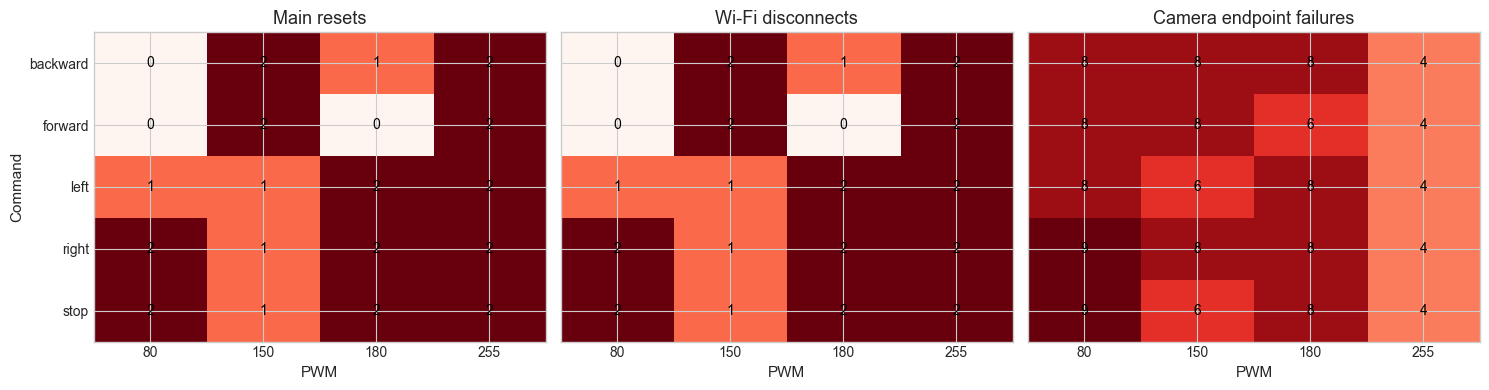

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
metrics = [
    ("resets", "Main resets"),
    ("wifi_disconnects", "Wi-Fi disconnects"),
    ("camera_losses", "Camera endpoint failures"),
]
for ax, (metric, title) in zip(axes, metrics):
    pivot = brownout_summary.pivot(index="command", columns="pwm", values=metric).fillna(0)
    im = ax.imshow(pivot.values, aspect="auto", cmap="Reds", vmin=0)
    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("PWM")
    for y in range(pivot.shape[0]):
        for x in range(pivot.shape[1]):
            ax.text(x, y, int(pivot.values[y, x]), ha="center", va="center", color="black")
axes[0].set_ylabel("Command")
plt.tight_layout()
plt.show()


## 8. ToF Calibration Summary

This section uses the calibration summary generated after comparing measured ToF values against real measured distance. The short/medium range is usable for obstacle logic; the long range still needs a retest after final mounting.


In [17]:
tof_cal = read_csv("tof_calibration_summary.csv")
tof_cal


,range_mm,model,mean_abs_corrected_error_mm,max_abs_corrected_error_mm,valid_for_control,notes
0,50-300,actual_mm = 1.1202 * measured_mm - 85.72,11.7,23.5,yes,Use for short/medium obstacle logic only; rete...
1,500,not reliable in current dataset,NaN,NaN,no,500 mm readings vary strongly and should not b...


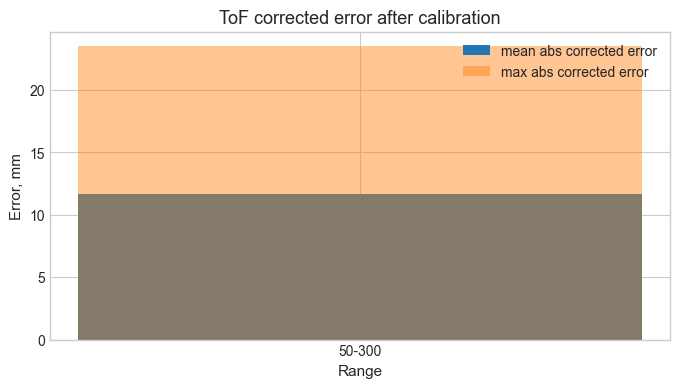

In [18]:
valid_tof = tof_cal.dropna(subset=["mean_abs_corrected_error_mm"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(valid_tof["range_mm"], valid_tof["mean_abs_corrected_error_mm"], label="mean abs corrected error")
ax.bar(valid_tof["range_mm"], valid_tof["max_abs_corrected_error_mm"], alpha=0.45, label="max abs corrected error")
ax.set_title("ToF corrected error after calibration")
ax.set_xlabel("Range")
ax.set_ylabel("Error, mm")
ax.legend()
plt.show()


## 9. Tap-Drive Accuracy

The tap-drive test records commanded arena targets and measured final positions. The red-target servo behavior is intentionally excluded because that actuator path is disabled in firmware.


In [19]:
tap = read_csv("tap_drive_accuracy_test.csv")
tap_summary = pd.DataFrame({
    "trials": [len(tap)],
    "median_position_error_mm": [tap["position_error_mm"].median()],
    "mean_position_error_mm": [tap["position_error_mm"].mean()],
    "max_position_error_mm": [tap["position_error_mm"].max()],
    "max_abs_heading_error_deg": [tap["heading_error_deg"].abs().max()],
    "passes": [(tap["result"] == "pass").sum()],
})
tap_summary.round(2)


,trials,median_position_error_mm,mean_position_error_mm,max_position_error_mm,max_abs_heading_error_deg,passes
0,5,20.0,43.28,141.4,10,5


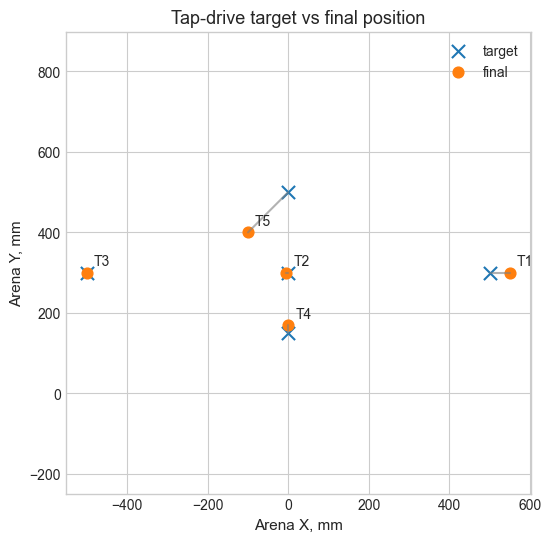

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(tap["target_x_mm"], tap["target_y_mm"], marker="x", s=90, label="target")
ax.scatter(tap["final_x_mm"], tap["final_y_mm"], marker="o", s=60, label="final")
for _, row in tap.iterrows():
    ax.plot([row["target_x_mm"], row["final_x_mm"]], [row["target_y_mm"], row["final_y_mm"]], color="gray", alpha=0.6)
    ax.annotate(row["target_id"], (row["final_x_mm"], row["final_y_mm"]), textcoords="offset points", xytext=(5, 5))
ax.set_title("Tap-drive target vs final position")
ax.set_xlabel("Arena X, mm")
ax.set_ylabel("Arena Y, mm")
ax.axis("equal")
ax.legend()
plt.show()


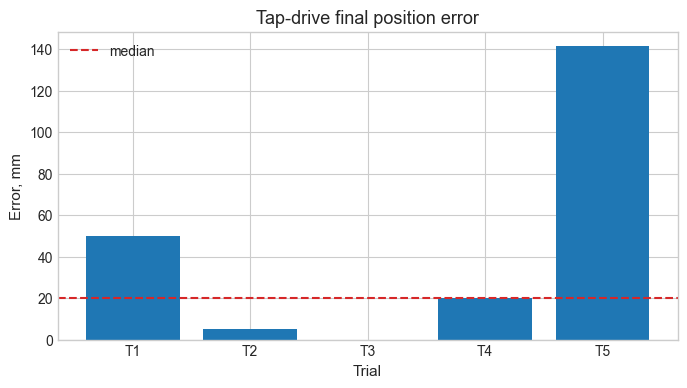

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tap["target_id"], tap["position_error_mm"])
ax.axhline(tap["position_error_mm"].median(), color="tab:red", linestyle="--", label="median")
ax.set_title("Tap-drive final position error")
ax.set_xlabel("Trial")
ax.set_ylabel("Error, mm")
ax.legend()
plt.show()


## 10. Camera Homography Calibration

The homography dataset maps clicked camera pixels to arena millimetres. Residuals show the current calibration quality and where a future calibration board/chessboard run would improve accuracy.


In [22]:
homography = read_csv("camera_homography_residuals.csv")
homography_summary = pd.DataFrame({
    "points": [len(homography)],
    "mean_error_mm": [homography["error_mm"].mean()],
    "median_error_mm": [homography["error_mm"].median()],
    "max_error_mm": [homography["error_mm"].max()],
})
homography_summary.round(2)


,points,mean_error_mm,median_error_mm,max_error_mm
0,6,43.62,44.95,68.3


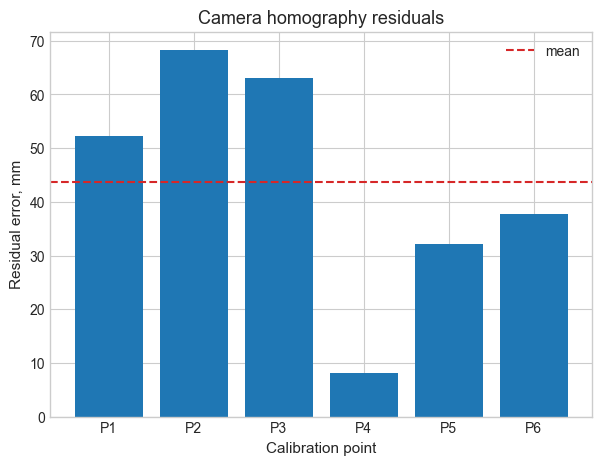

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(homography["point_id"], homography["error_mm"])
ax.axhline(homography["error_mm"].mean(), color="tab:red", linestyle="--", label="mean")
ax.set_title("Camera homography residuals")
ax.set_xlabel("Calibration point")
ax.set_ylabel("Residual error, mm")
ax.legend()
plt.show()


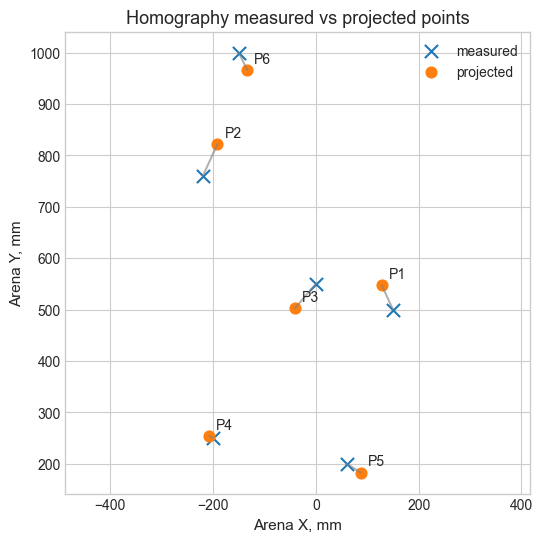

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(homography["arena_x_mm"], homography["arena_y_mm"], marker="x", s=90, label="measured")
ax.scatter(homography["projected_x_mm"], homography["projected_y_mm"], marker="o", s=60, label="projected")
for _, row in homography.iterrows():
    ax.plot([row["arena_x_mm"], row["projected_x_mm"]], [row["arena_y_mm"], row["projected_y_mm"]], color="gray", alpha=0.6)
    ax.annotate(row["point_id"], (row["projected_x_mm"], row["projected_y_mm"]), textcoords="offset points", xytext=(5, 5))
ax.set_title("Homography measured vs projected points")
ax.set_xlabel("Arena X, mm")
ax.set_ylabel("Arena Y, mm")
ax.axis("equal")
ax.legend()
plt.show()


## 11. Color Sensor Repeatability

The color test records repeated TCS34725 readings for red, light, and dark surfaces. The dark threshold was fixed in firmware after the old rule misclassified a dark surface as white.


In [25]:
color = read_csv("color_repeatability_test.csv")
color_summary = (
    color.groupby("surface")
    .agg(
        trials=("trial", "count"),
        clear_mean=("clear", "mean"),
        clear_std=("clear", "std"),
        red_mean=("red", "mean"),
        green_mean=("green", "mean"),
        blue_mean=("blue", "mean"),
        passes=("result", lambda s: (s == "pass").sum()),
    )
    .reset_index()
)
color_summary.round(2)


,surface,trials,clear_mean,clear_std,red_mean,green_mean,blue_mean,passes
0,dark,3,86.67,0.58,44.00,27.00,17.0,3
1,light,3,797.33,0.58,368.00,267.33,165.0,3
2,red,3,721.00,1.00,457.67,168.00,117.0,3


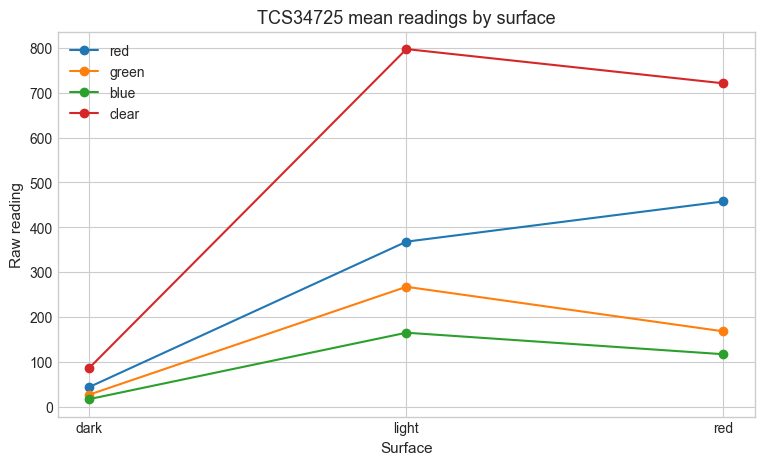

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
for channel in ["red", "green", "blue", "clear"]:
    means = color.groupby("surface")[channel].mean()
    ax.plot(means.index, means.values, marker="o", label=channel)
ax.set_title("TCS34725 mean readings by surface")
ax.set_xlabel("Surface")
ax.set_ylabel("Raw reading")
ax.legend()
plt.show()


In [27]:
classification = color[["surface", "trial", "ui_name_before_fix", "expected_name", "predicted_name_after_fix", "result", "notes"]]
classification


,surface,trial,ui_name_before_fix,expected_name,predicted_name_after_fix,result,notes
0,red,1,red,red,red,pass,NaN
1,red,2,red,red,red,pass,NaN
2,red,3,red,red,red,pass,NaN
3,light,1,unknown,white,white,pass,warm light surface
4,light,2,unknown,white,white,pass,warm light surface
5,light,3,unknown,white,white,pass,warm light surface
6,dark,1,white,dark,dark,pass,old threshold clear<35 misclassified this as w...
7,dark,2,white,dark,dark,pass,old threshold clear<35 misclassified this as w...
8,dark,3,white,dark,dark,pass,old threshold clear<35 misclassified this as w...


## 12. Auto Behavior Observation

The browser-side auto logger is implemented, but only one operator observation is available because the robot battery depleted before the full logger CSV could be collected. This is evidence of observed behavior, not a full reliability dataset.


In [28]:
auto_obs = read_csv("auto_behavior_operator_observation.csv")
auto_obs


,date,trial,obstacle_distance_mm,observed_action,result,source,notes
0,2026-06-17,1,200,turn_or_avoid,pass,operator_observation,Robot was observed turning/avoiding at approxi...


## 13. Power Brownout Retest Summary

The detailed brownout table is complemented by the 2026-06-17 retest summary, where camera presence was visually confirmed by the operator/browser.


In [29]:
brownout_retest = read_csv("power_brownout_retest_2026-06-17_summary.csv")
brownout_retest


,date,pwm,rows,reset_no,wifi_disconnect_no,camera_loss_no,camera_observed_rows,notes
0,2026-06-17,80,10,10,10,8,10,pass for power robustness
1,2026-06-17,150,10,10,10,10,10,pass for power robustness
2,2026-06-17,180,10,10,10,10,10,pass for power robustness


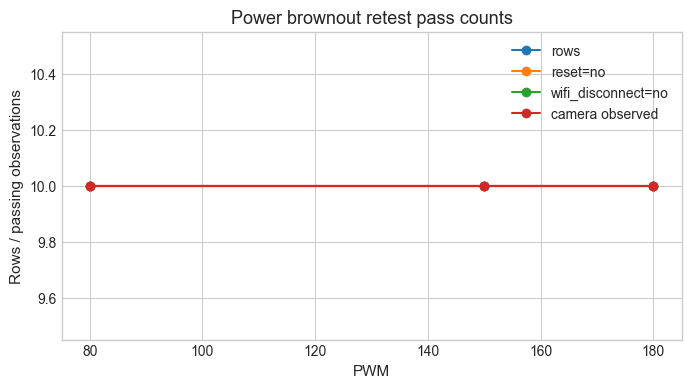

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(brownout_retest["pwm"], brownout_retest["rows"], marker="o", label="rows")
ax.plot(brownout_retest["pwm"], brownout_retest["reset_no"], marker="o", label="reset=no")
ax.plot(brownout_retest["pwm"], brownout_retest["wifi_disconnect_no"], marker="o", label="wifi_disconnect=no")
ax.plot(brownout_retest["pwm"], brownout_retest["camera_observed_rows"], marker="o", label="camera observed")
ax.set_title("Power brownout retest pass counts")
ax.set_xlabel("PWM")
ax.set_ylabel("Rows / passing observations")
ax.legend()
plt.show()


## 14. Current Engineering Conclusions

- HTTP manual-control latency is in a usable range for browser control.
- Movement, drift, and turn tests provide baseline drive measurements.
- ToF stop and calibration data support short/medium obstacle logic; long-range precision needs retesting.
- Tap-drive target tests show median position error around the tens-of-millimetres range, with one larger outlier.
- Camera homography works as a prototype calibration but should be improved with a real calibration board or denser marker set.
- TCS34725 color repeatability is documented for red, light, and dark surfaces after the dark-threshold firmware fix.
- Power brownout retest data supports stable operation at tested PWM values with camera observation.
- Autonomous behavior has logger support and one operator observation, but still needs a charged full multi-trial logger CSV before making a strong reliability claim.
